## Data Cleaning & Preprocessing

### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

### Load Dataset

In [2]:
hurricanes = pd.read_csv("hurricane_data.csv") # renamed kaggle csv from storms to hurricane_data

### Inspect Dataset

In [3]:
print("=== Dataset Dimensions ===")
print(hurricanes.shape)
print("\n=== First Five Observations ===")
print(hurricanes.head())
print("\n=== Dataset Information ===")
print(hurricanes.info())
print("\n=== Variable Names ===")
print(hurricanes.columns)

=== Dataset Dimensions ===
(22705, 13)

=== First Five Observations ===
       name  year  month  day  hour   lat  long               status  \
0  AL011975  1975      6   24    12  32.5 -52.0  tropical depression   
1  AL011975  1975      6   24    18  32.6 -52.6  tropical depression   
2  AL011975  1975      6   25     0  32.7 -53.2  tropical depression   
3  AL011975  1975      6   25    60  32.8 -53.2  tropical depression   
4  AL011975  1975      6   25    12  33.0 -54.5  tropical depression   

   category  wind  pressure  tropicalstorm_force_diameter  \
0       NaN    20      -999                         -1998   
1       NaN    25      -999                         -1998   
2       NaN    25      -999                         -1998   
3       NaN    25      -999                         -1998   
4       NaN    25      -999                         -1998   

   hurricane_force_diameter  
0                     -1998  
1                     -1998  
2                     -1998  
3       

### Handle Missing Values

In [4]:
# Replace NOAA missing value placeholder codes with NaN
hurricanes.replace([-999, -1998, -99], np.nan, inplace=True)

# Check missing values
print(hurricanes.isnull().sum())

name                                0
year                                0
month                               0
day                                 0
hour                                0
lat                                 0
long                               14
status                              0
category                        17543
wind                               39
pressure                         1918
tropicalstorm_force_diameter    11439
hurricane_force_diameter        11439
dtype: int64


NOTES:
The values -99, -999 and -1998 in the NOAA hurricane dataset represent placeholder codes used to indicate missing or unavailable observations. During preprocessing, these values were replaced with null (NaN) values to ensure accurate missing value analysis and prevent invalid measurements from affecting the modeling process.

features with missing values
*   category - should filter on hurricanes only
*   pressure - possibly impute with mean, median or mode. (median - best with outliers, mode - best for categorical)
*   tropicalstorm_force_diameter - possibly impute
*   hurricane_force_diameter - possibly impute




### Summary Statistics

In [5]:
print("=== Numerical Variable Summary ===")
display(hurricanes.describe())

print("=== Storm Status Distribution ===")
display(hurricanes['status'].value_counts())

print("=== Hurricane Category Counts ===")
display(hurricanes['category'].value_counts().sort_index())

=== Numerical Variable Summary ===


,year,month,day,hour,lat,long,category,wind,pressure,tropicalstorm_force_diameter,hurricane_force_diameter
count,22705.000000,22705.000000,22705.00000,22705.000000,22705.000000,22691.000000,5162.000000,22666.000000,20787.000000,11266.000000,11266.000000
mean,2001.987932,8.689055,15.75098,22.528254,26.606276,-61.252069,1.892871,48.322598,993.414586,148.130659,14.823806
std,14.388083,1.353205,8.93909,22.556684,10.393664,21.176148,1.149691,25.254954,18.782900,156.692478,33.856667
min,1975.000000,1.000000,1.00000,0.000000,7.000000,-136.900000,1.000000,10.000000,882.000000,0.000000,0.000000
25%,1990.000000,8.000000,8.00000,12.000000,18.000000,-78.700000,1.000000,30.000000,986.000000,0.000000,0.000000
50%,2003.000000,9.000000,16.00000,18.000000,26.000000,-61.700000,1.000000,40.000000,1000.000000,120.000000,0.000000
75%,2015.000000,9.000000,24.00000,22.000000,33.400000,-45.200000,3.000000,60.000000,1007.000000,220.000000,0.000000
max,2024.000000,12.000000,31.00000,94.000000,70.700000,13.500000,5.000000,165.000000,1024.000000,1440.000000,300.000000


=== Storm Status Distribution ===


status
tropical storm            7339
tropical depression       5352
hurricane                 5162
extratropical             2370
other low                 1623
subtropical storm          333
disturbance                214
subtropical depression     174
tropical wave              138
Name: count, dtype: int64

=== Hurricane Category Counts ===


category
1.0    2744
2.0    1071
3.0     632
4.0     586
5.0     129
Name: count, dtype: int64

In [6]:
print("=== Descriptive Statistics (All Variables) ===")
display(hurricanes.describe(include='all'))

print("=== Storm Status Distribution ===")
status_counts = hurricanes['status'].value_counts()
display(status_counts)

print("=== Hurricane Category Counts ===")
category_counts = hurricanes['category'].value_counts().sort_index()
display(category_counts)

=== Descriptive Statistics (All Variables) ===


,name,year,month,day,hour,lat,long,status,category,wind,pressure,tropicalstorm_force_diameter,hurricane_force_diameter
count,22705,22705.000000,22705.000000,22705.00000,22705.000000,22705.000000,22691.000000,22705,5162.000000,22666.000000,20787.000000,11266.000000,11266.000000
unique,383,NaN,NaN,NaN,NaN,NaN,NaN,9,NaN,NaN,NaN,NaN,NaN
top,Bonnie,NaN,NaN,NaN,NaN,NaN,NaN,tropical storm,NaN,NaN,NaN,NaN,NaN
freq,328,NaN,NaN,NaN,NaN,NaN,NaN,7339,NaN,NaN,NaN,NaN,NaN
mean,NaN,2001.987932,8.689055,15.75098,22.528254,26.606276,-61.252069,NaN,1.892871,48.322598,993.414586,148.130659,14.823806
std,NaN,14.388083,1.353205,8.93909,22.556684,10.393664,21.176148,NaN,1.149691,25.254954,18.782900,156.692478,33.856667
min,NaN,1975.000000,1.000000,1.00000,0.000000,7.000000,-136.900000,NaN,1.000000,10.000000,882.000000,0.000000,0.000000
25%,NaN,1990.000000,8.000000,8.00000,12.000000,18.000000,-78.700000,NaN,1.000000,30.000000,986.000000,0.000000,0.000000
50%,NaN,2003.000000,9.000000,16.00000,18.000000,26.000000,-61.700000,NaN,1.000000,40.000000,1000.000000,120.000000,0.000000
75%,NaN,2015.000000,9.000000,24.00000,22.000000,33.400000,-45.200000,NaN,3.000000,60.000000,1007.000000,220.000000,0.000000


=== Storm Status Distribution ===


status
tropical storm            7339
tropical depression       5352
hurricane                 5162
extratropical             2370
other low                 1623
subtropical storm          333
disturbance                214
subtropical depression     174
tropical wave              138
Name: count, dtype: int64

=== Hurricane Category Counts ===


category
1.0    2744
2.0    1071
3.0     632
4.0     586
5.0     129
Name: count, dtype: int64

## Exploratory Data Analysis (EDA) 

### Distribution Analysis

#### Wind Speed and Pressure Histogram

In [7]:
print(hurricanes[['wind', 'pressure']].describe())

               wind      pressure
count  22666.000000  20787.000000
mean      48.322598    993.414586
std       25.254954     18.782900
min       10.000000    882.000000
25%       30.000000    986.000000
50%       40.000000   1000.000000
75%       60.000000   1007.000000
max      165.000000   1024.000000


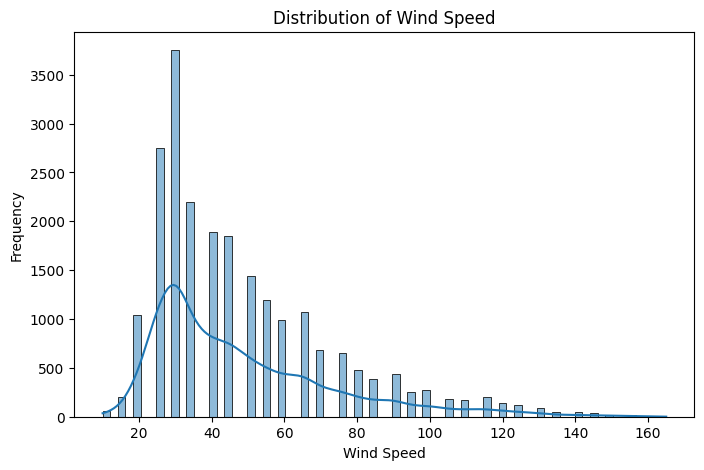

In [8]:
plt.figure(figsize=(8, 5))
sns.histplot(hurricanes['wind'], kde=True)

plt.title("Distribution of Wind Speed")
plt.xlabel("Wind Speed")
plt.ylabel("Frequency")

plt.show()

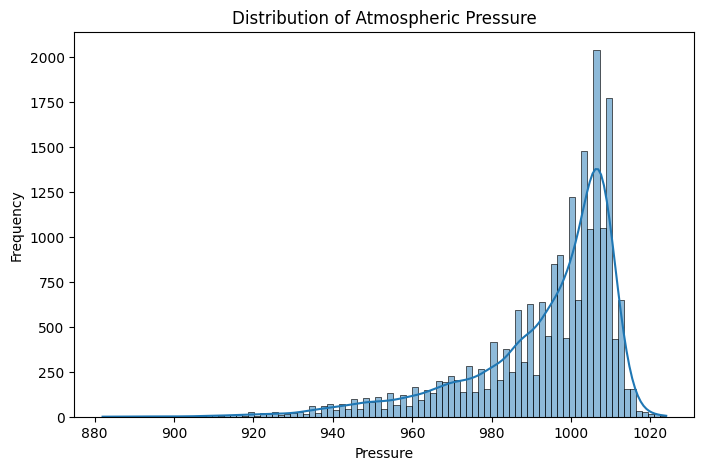

In [9]:
plt.figure(figsize=(8, 5))
sns.histplot(hurricanes['pressure'], kde=True)

plt.title("Distribution of Atmospheric Pressure")
plt.xlabel("Pressure")
plt.ylabel("Frequency")

plt.show()

NOTES:

Most storms in the dataset had moderate wind speeds and relatively high atmospheric pressure, while a smaller number of storms reached extreme hurricane conditions. Wind speeds ranged from 10 mph to 165 mph, with most observations concentrated between 30 and 60 mph. The wind speed distribution is right-skewed, meaning there are fewer extremely intense storms compared to weaker storms.

The atmospheric pressure distribution shows that most storms had pressure values near 1000 mb, while a smaller number of storms had much lower pressure values. Since lower atmospheric pressure is generally associated with stronger hurricanes, the left tail of the distribution likely represents major hurricanes and intense storm systems.

#### Category Distribution


In [10]:
print(hurricanes['category'].value_counts())

category
1.0    2744
2.0    1071
3.0     632
4.0     586
5.0     129
Name: count, dtype: int64


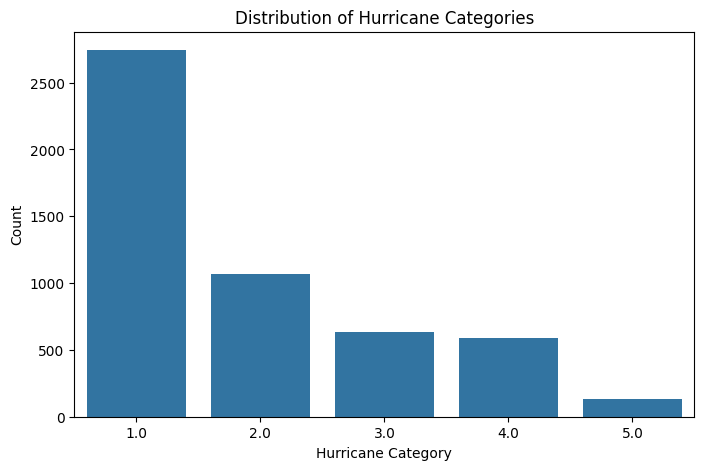

In [11]:
plt.figure(figsize=(8, 5))
sns.countplot(x='category', data=hurricanes)

plt.title("Distribution of Hurricane Categories")
plt.xlabel("Hurricane Category")
plt.ylabel("Count")

plt.show()

#### Class Imbalance Table

In [12]:
print("=== Hurricane Category Counts ===")

category_counts = hurricanes['category'].value_counts().sort_index()
display(category_counts)

print("=== Hurricane Category Percentages ===")

category_percentages = hurricanes['category'].value_counts(normalize=True).sort_index() * 100
display(category_percentages.round(2))

=== Hurricane Category Counts ===


category
1.0    2744
2.0    1071
3.0     632
4.0     586
5.0     129
Name: count, dtype: int64

=== Hurricane Category Percentages ===


category
1.0    53.16
2.0    20.75
3.0    12.24
4.0    11.35
5.0     2.50
Name: proportion, dtype: float64

NOTES: The category distribution is imbalanced. Category 1 storms make up 53.16%, while Category 5 storms make up only 2.50%.

### Boxplot Analysis

#### Pressure by Category

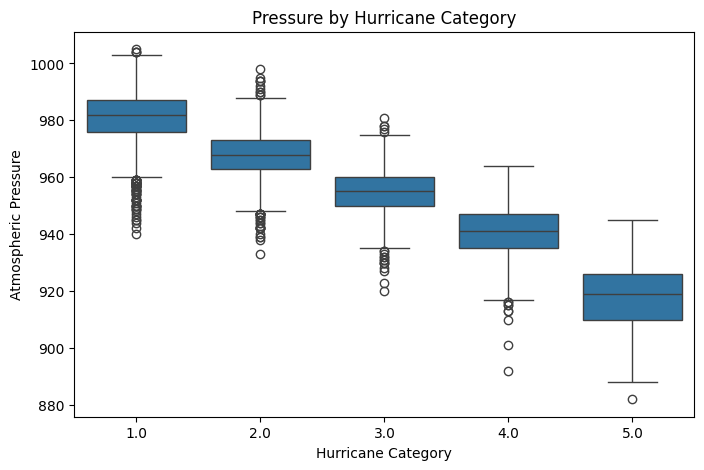

In [13]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x='category',
    y='pressure',
    data=hurricanes
)

plt.title("Pressure by Hurricane Category")
plt.xlabel("Hurricane Category")
plt.ylabel("Atmospheric Pressure")
plt.show()

#### Wind by Category

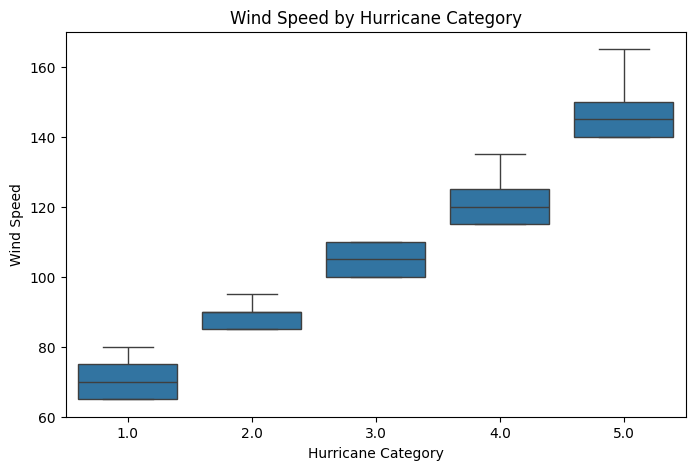

In [14]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x='category',
    y='wind',
    data=hurricanes
)

plt.title("Wind Speed by Hurricane Category")
plt.xlabel("Hurricane Category")
plt.ylabel("Wind Speed")
plt.show()

NOTES: The boxplots show that pressure decreases as hurricane category increases, while wind speed increases as category increases. The wind-pressure scatter plot also shows a clear inverse relationship.

### Scatter Plot Analysis

#### Wind vs Pressure

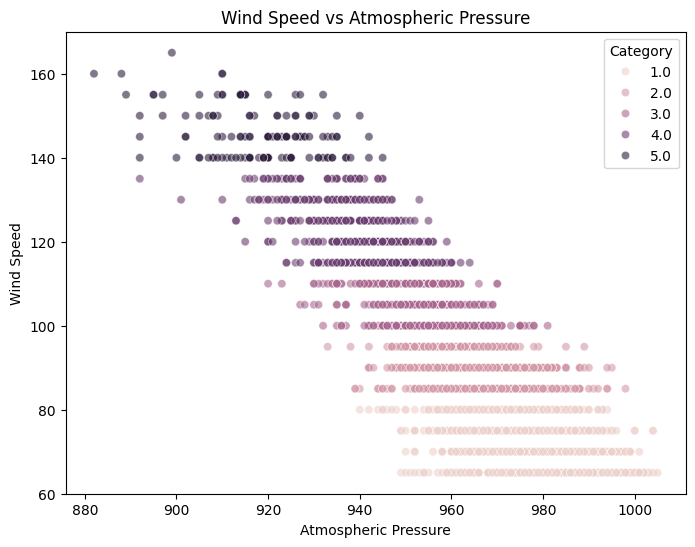

In [15]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    x='pressure',
    y='wind',
    hue='category',
    data=hurricanes,
    alpha=0.6
)

plt.title("Wind Speed vs Atmospheric Pressure")
plt.xlabel("Atmospheric Pressure")
plt.ylabel("Wind Speed")
plt.legend(title="Category")
plt.show()

NOTES: Strong Negative Relationship
The points form a clear downward trend from left to right:

* As atmospheric pressure decreases, wind speed increases.
* As atmospheric pressure increases, wind speed decreases.

This indicates a strong negative correlation between pressure and wind speed.

* Category 1 hurricanes tend to have pressures around 970–1000 mb and wind speeds around 65–85 mph.
* Category 5 hurricanes tend to have pressures around 880–930 mb and wind speeds above 140 mph.

Why the Lines Appear Horizontal? wind speed is recorded in discrete increments (typically every 5 mph), so many observations share the same wind speed value.

Hurricane Categories Separate Naturally. The colors form distinct bands:

* Category 1 storms cluster at high pressure and lower wind speeds.
* Categories 2–4 appear in the middle ranges.
* Category 5 storms cluster at the lowest pressures and highest wind speeds.

#### Geographic Hurricane Distribution

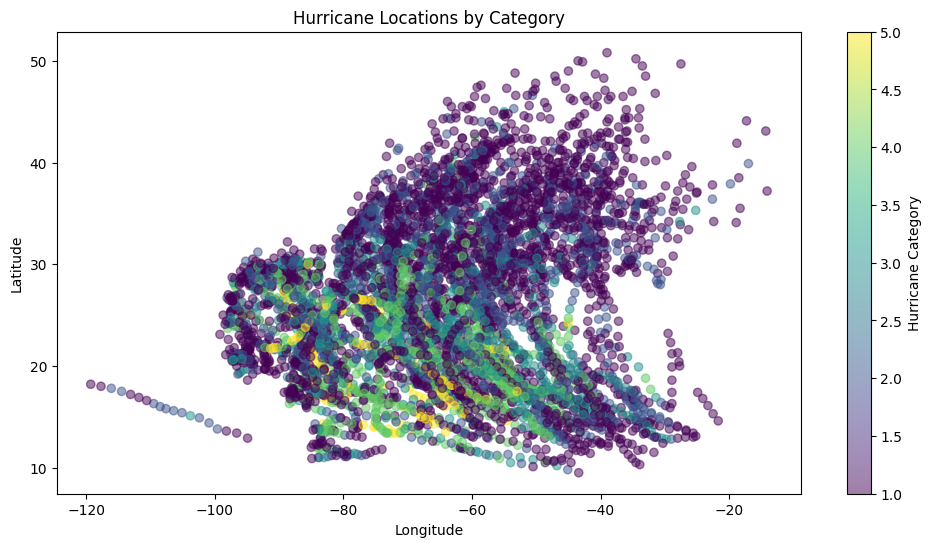

In [16]:
plt.figure(figsize=(12,6))

scatter = plt.scatter(
    hurricanes['long'],
    hurricanes['lat'],
    c=hurricanes['category'],
    cmap='viridis',
    alpha=0.5
)

plt.colorbar(scatter, label='Hurricane Category')
plt.title("Hurricane Locations by Category")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

### Correlation Analysis

#### Correlation Matrix

In [17]:
print("=== Correlation Matrix ===")
numeric_cols = hurricanes.select_dtypes(include='number')
correlation_matrix = numeric_cols.corr()
display(correlation_matrix)

=== Correlation Matrix ===


,year,month,day,hour,lat,long,category,wind,pressure,tropicalstorm_force_diameter,hurricane_force_diameter
year,1.000000,-0.015537,-0.021302,0.009973,0.023817,0.036965,0.097078,0.083462,-0.024283,0.003764,-0.036938
month,-0.015537,1.000000,-0.164694,0.000232,-0.030127,0.108308,-0.015781,0.129675,-0.149525,0.142267,0.108255
day,-0.021302,-0.164694,1.000000,-0.000918,-0.029223,0.023567,-0.084152,-0.025178,0.024065,-0.008331,-0.005564
hour,0.009973,0.000232,-0.000918,1.000000,0.000725,-0.008744,0.010385,0.012953,-0.011977,0.006198,0.005099
lat,0.023817,-0.030127,-0.029223,0.000725,1.000000,0.113780,-0.313073,0.029591,-0.121031,0.407398,0.075140
long,0.036965,0.108308,0.023567,-0.008744,0.113780,1.000000,-0.181528,-0.040888,0.049321,0.101366,-0.076337
category,0.097078,-0.015781,-0.084152,0.010385,-0.313073,-0.181528,1.000000,0.965788,-0.869548,0.048911,0.314611
wind,0.083462,0.129675,-0.025178,0.012953,0.029591,-0.040888,0.965788,1.000000,-0.928066,0.536108,0.720014
pressure,-0.024283,-0.149525,0.024065,-0.011977,-0.121031,0.049321,-0.869548,-0.928066,1.000000,-0.640515,-0.767657
tropicalstorm_force_diameter,0.003764,0.142267,-0.008331,0.006198,0.407398,0.101366,0.048911,0.536108,-0.640515,1.000000,0.519997


#### Correlation Heatmap

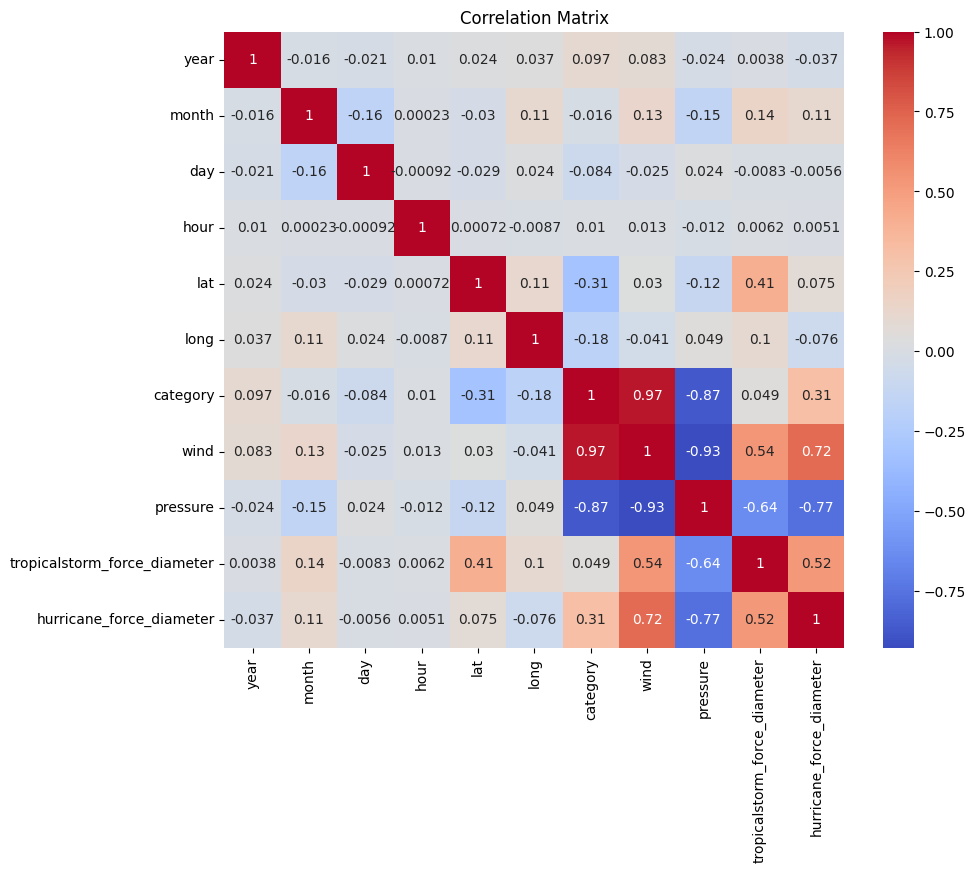

In [18]:
numeric_cols = hurricanes.select_dtypes(include='number')
corr = numeric_cols.corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

NOTES:

The correlation matrix shows several strong relationships between hurricane intensity variables, particularly among hurricane category, wind speed, and atmospheric pressure. The strongest positive correlation appears between hurricane category and wind speed (0.97), indicating that stronger hurricane categories are closely associated with higher wind speeds.

Atmospheric pressure shows a strong negative correlation with both hurricane category (-0.87) and wind speed (-0.93). This means that as wind speed and hurricane intensity increase, atmospheric pressure generally decreases.

The hurricane force diameter variable also shows a moderately strong positive relationship with wind speed (0.72), suggesting that storms with stronger winds tend to have larger hurricane-force wind fields. Similarly, tropical storm force diameter has a moderate positive correlation with wind speed (0.54), indicating that larger storms may also be associated with increased storm intensity.

Most temporal variables such as year, month, day, and hour show relatively weak correlations with hurricane intensity variables, suggesting that storm strength is more strongly influenced by environmental and storm-specific characteristics rather than calendar-based variables alone.

### Outlier Analysis

#### Wind Outliers

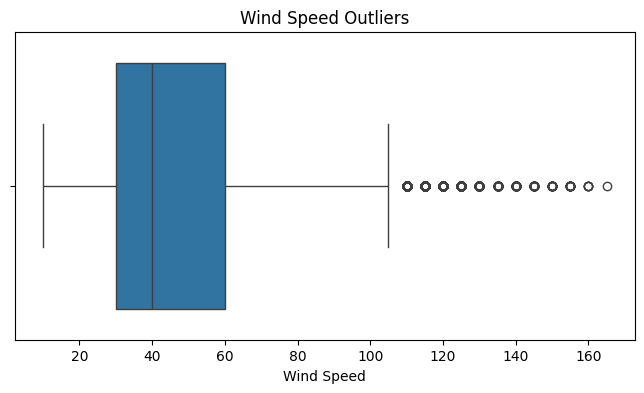

In [19]:
plt.figure(figsize=(8, 4))

sns.boxplot(
    x=hurricanes['wind']
)

plt.title("Wind Speed Outliers")
plt.xlabel("Wind Speed")
plt.show()

#### Pressure Outliers

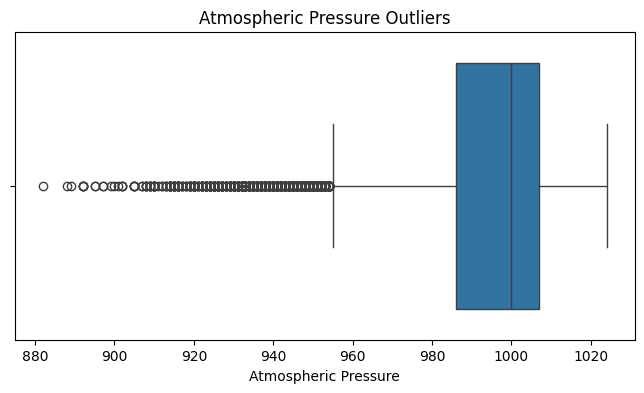

In [20]:
plt.figure(figsize=(8, 4))

sns.boxplot(
    x=hurricanes['pressure']
)

plt.title("Atmospheric Pressure Outliers")
plt.xlabel("Atmospheric Pressure")
plt.show()

#### Calculate Outliers Using IQR

In [21]:
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    
    print(f"=== {column} Outlier Summary ===")
    print(f"Lower Bound: {lower_bound}")
    print(f"Upper Bound: {upper_bound}")
    print(f"Number of Outliers: {outliers.shape[0]}")
    
    return outliers

wind_outliers = detect_outliers_iqr(hurricanes, 'wind')
pressure_outliers = detect_outliers_iqr(hurricanes, 'pressure')

=== wind Outlier Summary ===
Lower Bound: -15.0
Upper Bound: 105.0
Number of Outliers: 891
=== pressure Outlier Summary ===
Lower Bound: 954.5
Upper Bound: 1038.5
Number of Outliers: 1133


NOTES: Outliers were identified in both wind and pressure. The IQR method found 891 wind outliers and 1,133 pressure outliers; these likely represent valid extreme hurricane observations

### Variable Relationship Summary

#### Strongest Relationships

In [22]:
print("=== Strongest Correlations with Hurricane Category ===")

category_correlations = correlation_matrix['category'].sort_values(ascending=False)

display(category_correlations)

=== Strongest Correlations with Hurricane Category ===


category                        1.000000
wind                            0.965788
hurricane_force_diameter        0.314611
year                            0.097078
tropicalstorm_force_diameter    0.048911
hour                            0.010385
month                          -0.015781
day                            -0.084152
long                           -0.181528
lat                            -0.313073
pressure                       -0.869548
Name: category, dtype: float64

#### Potential Predictors

In [23]:
print("=== Potential Predictor Variables Based on EDA ===")

potential_predictors = [
    'wind',
    'pressure',
    'hurricane_force_diameter',
    'tropicalstorm_force_diameter',
    'lat',
    'long',
    'status'
]

for predictor in potential_predictors:
    print(predictor)

=== Potential Predictor Variables Based on EDA ===
wind
pressure
hurricane_force_diameter
tropicalstorm_force_diameter
lat
long
status


#### Clean Summary Table

In [24]:
predictor_summary = pd.DataFrame({
    "Variable": [
        "wind",
        "pressure",
        "hurricane_force_diameter",
        "tropicalstorm_force_diameter",
        "lat",
        "long",
        "status"
    ],
    "Reason for Inclusion": [
        "Strong positive relationship with hurricane category",
        "Strong negative relationship with hurricane category and wind speed",
        "Moderate positive relationship with wind speed",
        "Moderate relationship with storm size and intensity",
        "Geographic location may help explain storm development patterns",
        "Geographic location may help explain storm tracks and intensity",
        "Storm classification stage may provide predictive information"
    ]
})

display(predictor_summary)

,Variable,Reason for Inclusion
0,wind,Strong positive relationship with hurricane ca...
1,pressure,Strong negative relationship with hurricane ca...
2,hurricane_force_diameter,Moderate positive relationship with wind speed
3,tropicalstorm_force_diameter,Moderate relationship with storm size and inte...
4,lat,Geographic location may help explain storm dev...
5,long,Geographic location may help explain storm tra...
6,status,Storm classification stage may provide predict...


## 5. Clustering & Principal Component Analysis (PCA) 
 Unsupervised Learning

 Unlike supervised learning methods, which use hurricane categories as the target variable, unsupervised learning explores the data without predefined labels to identify natural patterns and relationships among storms. Building on the completed data preprocessing and exploratory data analysis, K-Means clustering and Hierarchical Clustering were applied to group hurricanes based on similarities in their physical and environmental characteristics, including wind speed, atmospheric pressure, geographic location, and storm size. Principal Component Analysis (PCA) was then performed to reduce the dimensionality of the dataset while preserving as much information as possible, allowing the cluster structure to be visualized in two dimensions. These techniques provide additional insight into hurricane behavior and help determine whether storms naturally form distinct groups based on their observed characteristics rather than their assigned hurricane categories.

**K-Means Clustering**

K-Means clustering was applied to identify natural groupings of hurricanes based on similarities in their environmental and physical characteristics. 
Unlike supervised learning methods, K-Means does not use hurricane category labels; instead, it partitions observations into clusters by minimizing the distance between observations and their assigned cluster centers. 
Before clustering, all variables were standardized to ensure that differences in measurement scales did not influence the clustering results.

In [25]:
# Select Features
# Variables selected from the EDA
cluster_data = hurricanes[
    [
        'wind',
        'pressure',
        'hurricane_force_diameter',
        'tropicalstorm_force_diameter',
        'lat',
        'long'
    ]
].copy()

In [26]:
# Missing Values
cluster_data = cluster_data.fillna(cluster_data.median())

# Standardize
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(cluster_data)

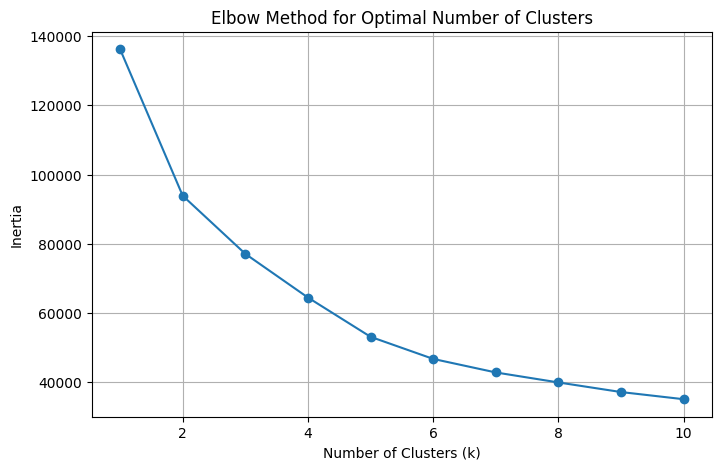

In [27]:
# Elbow Method
# Determine the Optimal Number of Clusters
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

K = range(1, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K, inertia, marker='o')
plt.title('Elbow Method for Optimal Number of Clusters')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()

The Elbow Method was used to determine the optimal number of clusters by examining the relationship between the number of clusters and the within-cluster sum of squares (inertia). The curve begins to level off at approximately k = 5, indicating diminishing returns from adding additional clusters. Therefore, five clusters were selected for the K-Means analysis because they provide a good balance between model simplicity and cluster separation.

In [28]:
# Fit the K-Means Model

from sklearn.cluster import KMeans
kmeans = KMeans(
    n_clusters=5,         # Replace no. of clusters with (k) above
    random_state=42,
    n_init=10
)
cluster_data["Cluster"] = kmeans.fit_predict(X_scaled)

# Number of hurricanes in each cluster
cluster_data["Cluster"].value_counts().sort_index()

Cluster
0    3127
1    6153
2    8066
3    4105
4    1254
Name: count, dtype: int64

The K-Means algorithm successfully partitioned the hurricane observations into five distinct clusters. The clusters are not perfectly equal in size, which is expected because K-Means groups observations based on similarity rather than forcing equal-sized groups.

Cluster 2 contains the largest number of observations (8,066), suggesting that many storms share similar environmental characteristics. Cluster 4 is the smallest (1,254 observations), indicating a smaller group of storms with more distinct characteristics, which may represent the most intense or least common storm behavior patterns.

**Why aren't the clusters the same size?**

K-Means minimizes the distance between observations within each cluster. It does not try to create equally sized groups, so clusters naturally vary in size depending on how the data are distributed.

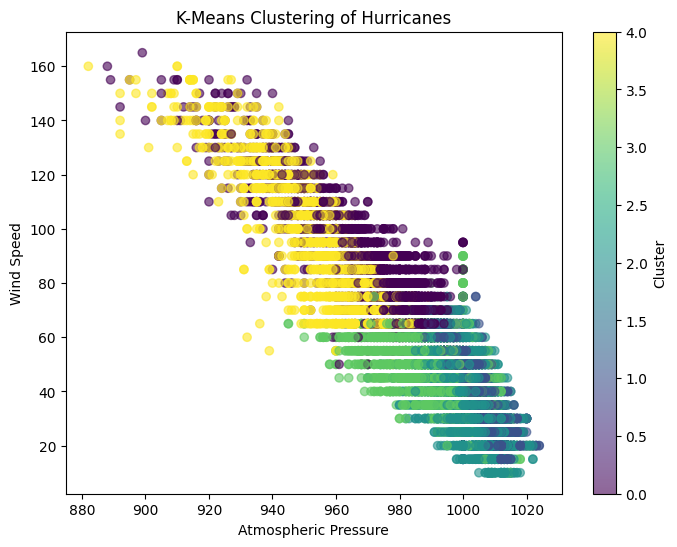

In [29]:
# Visualize the K-Means Clusters

import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(
    cluster_data["pressure"],
    cluster_data["wind"],
    c=cluster_data["Cluster"],
    cmap="viridis",
    alpha=0.6
)

plt.title("K-Means Clustering of Hurricanes")
plt.xlabel("Atmospheric Pressure")
plt.ylabel("Wind Speed")
plt.colorbar(label="Cluster")

plt.show()

The K-Means clustering algorithm successfully grouped the hurricane observations into five distinct clusters based on similarities in wind speed, atmospheric pressure, storm size, and geographic location. The scatter plot shows a clear inverse relationship between atmospheric pressure and wind speed, where storms with lower atmospheric pressure generally have higher wind speeds, while storms with higher pressure tend to have lower wind speeds.

Although the clusters overlap slightly, they form recognizable groups that represent different hurricane characteristics. Stronger storms are concentrated in the lower-pressure, higher-wind region of the plot, while weaker storms appear in the higher-pressure, lower-wind region. This demonstrates that hurricanes naturally group together based on their physical characteristics, even without using hurricane category labels.

**What insights did clustering reveal?**

"K-Means identified five natural groups of hurricanes based on their physical characteristics. The clusters largely followed the inverse relationship between atmospheric pressure and wind speed observed during the EDA. Stronger storms clustered together with lower pressures and higher wind speeds, while weaker storms formed separate groups with higher pressures and lower wind speeds. This shows that hurricanes exhibit natural behavioral patterns without relying on predefined category labels."

**Hierarchical Clustering**

Hierarchical clustering was performed to further examine the natural grouping of hurricanes. Unlike K-Means, hierarchical clustering does not require specifying the number of clusters in advance. Instead, it builds a hierarchy of clusters by successively merging the most similar observations. The resulting dendrogram provides a visual representation of how hurricanes are grouped based on their similarities.

In [30]:
# Import Libraries for Hierarchical Clustering
from scipy.cluster.hierarchy import linkage, dendrogram

# Compute the Linkage Matrix
linked = linkage(X_scaled, method='ward')

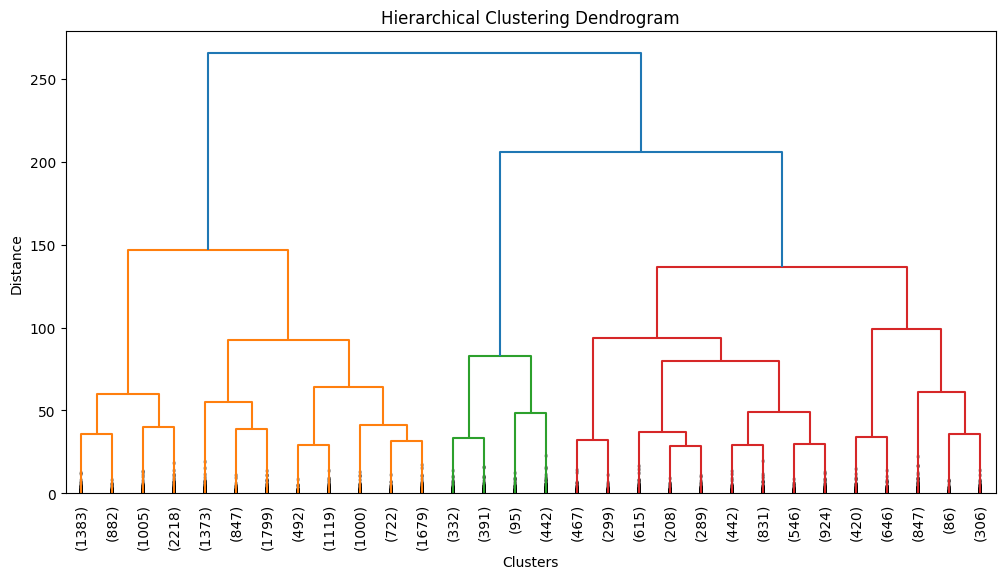

In [31]:
# Plot the Hierarchical Clustering Dendrogram

import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))

dendrogram(
    linked,
    truncate_mode='lastp',
    p=30,
    leaf_rotation=90,
    leaf_font_size=10,
    show_contracted=True
)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Clusters")
plt.ylabel("Distance")

plt.show()

The hierarchical clustering dendrogram illustrates how hurricane observations are progressively merged into larger clusters based on their similarity. The vertical axis represents the linkage distance, where shorter branches indicate more similar observations and taller branches indicate greater differences between groups.

The dendrogram shows several well-defined branches before the final merges occur, suggesting that the hurricane data naturally forms multiple distinct groups. The large increase in linkage distance near the top of the dendrogram indicates that combining the final groups would merge observations that are substantially different from one another. These results are consistent with the K-Means analysis, supporting the decision to use **five clusters** to represent the underlying structure of the hurricane dataset.

***Why use Hierarchical Clustering if you already used K-Means?**

"K-Means requires us to specify the number of clusters beforehand, while Hierarchical Clustering builds a tree of relationships without making that assumption. The dendrogram allows us to visually examine how observations merge together and serves as a way to validate the cluster structure found by K-Means."

**Principal Component Analysis (PCA)**

Principal Component Analysis (PCA) was performed to reduce the dimensionality of the hurricane dataset while preserving as much of the original variation as possible. PCA transforms the original variables into a smaller set of uncorrelated principal components, making it easier to visualize the data and identify patterns. The principal components were then used to display the hurricane clusters identified by the K-Means algorithm in two dimensions.

In [32]:
# Import PCA
from sklearn.decomposition import PCA

# Perform Principal Component Analysis (PCA)
pca = PCA(n_components=2)
principal_components = pca.fit_transform(X_scaled)

In [33]:
# Calculate the Explained Variance
explained_variance = pca.explained_variance_ratio_

print("Principal Component 1:", explained_variance[0])
print("Principal Component 2:", explained_variance[1])
print("Total Explained Variance:", explained_variance.sum())

Principal Component 1: 0.4565685020781472
Principal Component 2: 0.19952050923110362
Total Explained Variance: 0.6560890113092508


The first principal component (PC1) explains **45.66%** of the total variance in the hurricane dataset, while the second principal component (PC2) explains **19.95%**. Together, the first two principal components account for approximately **65.61%** of the total variance.

This indicates that the two principal components preserve a substantial amount of the information contained in the original variables while reducing the dataset from six dimensions to two. As a result, PCA provides an effective way to visualize the hurricane data and evaluate how well the K-Means clusters are separated in a two-dimensional space.

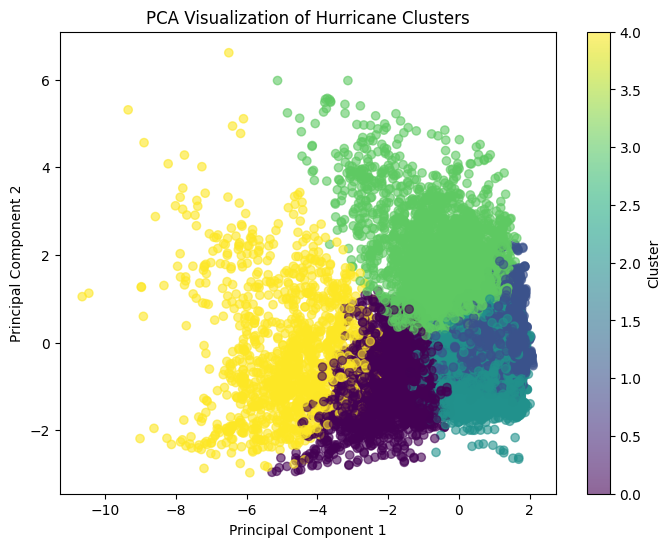

In [34]:
# PCA Scatter Plot
# Create a DataFrame with the Principal Components

import pandas as pd
import matplotlib.pyplot as plt

pca_df = pd.DataFrame(
    principal_components,
    columns=["Principal Component 1", "Principal Component 2"]
)

pca_df["Cluster"] = cluster_data["Cluster"]

# Visualize the PCA Results

plt.figure(figsize=(8,6))

plt.scatter(
    pca_df["Principal Component 1"],
    pca_df["Principal Component 2"],
    c=pca_df["Cluster"],
    cmap="viridis",
    alpha=0.6
)

plt.title("PCA Visualization of Hurricane Clusters")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(label="Cluster")

plt.show()



The PCA scatter plot displays the hurricane observations using the first two principal components, which together explain **65.61%** of the total variance in the dataset. Reducing the dataset to two dimensions makes it easier to visualize the overall structure while retaining most of the information contained in the original variables.

The visualization shows that the five K-Means clusters form several distinct groups, although some overlap is present. This overlap is expected because PCA compresses six original variables into only two principal components. Despite this reduction, the clusters remain reasonably well separated, indicating that the K-Means algorithm successfully identified meaningful patterns in the hurricane data. Overall, PCA confirms that hurricanes naturally group according to similarities in their physical and environmental characteristics.

**Conclusion**

Unsupervised learning techniques were successfully applied to identify natural patterns within the hurricane dataset. The Elbow Method suggested that five clusters provided an appropriate balance between model simplicity and cluster separation. K-Means clustering grouped hurricanes based on similarities in wind speed, atmospheric pressure, storm size, and geographic location, while Hierarchical Clustering produced a dendrogram that supported the presence of multiple distinct groups. Principal Component Analysis reduced the six original variables to two principal components that explained **65.61%** of the total variance, allowing the clusters to be visualized effectively. Together, these methods demonstrated that hurricanes exhibit meaningful natural groupings even without using hurricane category labels.

In [35]:
import plotly.express as px

fig = px.scatter(
    pca_df,
    x="Principal Component 1",
    y="Principal Component 2",
    color=pca_df["Cluster"].astype(str),
    title="Interactive PCA Visualization of Hurricane Clusters",
    labels={"color": "Cluster"},
    opacity=0.7
)

fig.show()